Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
Data Science - sección 40

Cristian Túnchez (231359)  
Nadissa López (23764)

# Laboratorio 4 (Parte 2): Preparación del conjunto de datos para Machine Learning

Este notebook cubre los **ejercicios 1, 2 y 3** de la segunda parte del laboratorio:

1. Construcción del conjunto de datos tabular a partir de los rásters de la Parte 1.
2. Construcción y justificación de la variable respuesta binaria.
3. Selección y construcción de las variables predictoras.

Inicia con los productos guardados en `data/processed/` por el notebook `01_obtencion_de_datos.ipynb`: los GeoTIFF de índices por lago y fecha, y la máscara fija del espejo de agua de cada lago. El entrenamiento y la evaluación de los modelos (ejercicios 4 al 10) se desarrollan en `04_modelos_cianobacteria.ipynb`.

**Preparación del entorno**

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_auc_score

# La carpeta src/ contiene los scripts
sys.path.insert(0, str(Path.cwd().parent / "src"))

import config
import dataset_ml as dml
import procesar

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

LAGOS = list(config.FECHAS)
COLOR = {"Atitlan": "#1f77b4", "Amatitlan": "#d62728"}
COLOR_CLASE = {0: "#4c72b0", 1: "#c44e52"}

print("Umbral de la variable respuesta:", dml.UMBRAL_CHLA_OMS, "mg/m3")
print("Variables predictoras:", len(dml.PREDICTORES))
print("Excluidas por fuga   :", len(dml.EXCLUIDAS_POR_FUGA))

Umbral de la variable respuesta: 10.0 mg/m3
Variables predictoras: 13
Excluidas por fuga   : 6


---

## Ejercicio 1 — Preparación de los datos para Machine Learning

### 1.1 Construcción del conjunto de datos

La Parte 1 dejó la información en forma de rásters, por cada lago y fecha, un GeoTIFF con las capas de índices, y una máscara fija del espejo de agua. Para entrenar modelos de clasificación hace falta lo contrario, una tabla donde **cada fila sea una observación**.

La unidad de observación que se elige es **un píxel de 20 × 20 m dentro de un lago, en una fecha concreta**. Un mismo píxel aparece por tanto hasta 11 veces, una por cada escena disponible de su lago. Toda la lógica está en el módulo `src/dataset_ml.py`, que reutiliza las funciones de lectura de la Parte 1 (`procesar.leer_indices`, `procesar.leer_mascara_lago`, `indices._leer`) y añade las variables que los rásters no traían.

In [2]:
if dml.RUTA_DATASET.exists():
    datos = dml.cargar_dataset()
    print("Dataset leido de:", dml.RUTA_DATASET.name)
else:
    datos = dml.construir_dataset()

print("Observaciones:", f"{len(datos):,}")
print("Variables    :", len(datos.columns))
datos.head()

Dataset leido de: dataset_ml.csv
Observaciones: 401,656
Variables    : 28


,lago,fecha,fila,columna,x_utm,y_utm,bloque_1km,B02,B03,B07,B08,B8A,B11,B12,ndwi,mndwi,ndmi,distancia_orilla_m,mes,estacion_lluviosa,B04,B05,ndci,ndvi,fai,chla,nubosidad_pct,y_alta
0,Atitlan,2025-01-18,226,770,695570.0,1627150.0,Atitlan_695_1627,0.0713,0.0441,0.0137,0.0108,0.0110,0.0021,0.0017,0.606557,0.909091,0.674419,3185.216064,1,0,0.0209,0.0182,-0.069054,-0.318612,-0.001359,1.645519,0.02,0
1,Atitlan,2025-01-18,281,790,695970.0,1626050.0,Atitlan_695_1626,0.0699,0.0439,0.0131,0.0114,0.0111,0.0023,0.0008,0.587704,0.900433,0.664234,2854.399902,1,0,0.0214,0.0176,-0.097436,-0.304878,-0.002223,0.000000,0.02,0
2,Atitlan,2025-01-18,228,763,695430.0,1627110.0,Atitlan_695_1627,0.0704,0.0437,0.0138,0.0115,0.0104,0.0022,0.0017,0.583333,0.904140,0.678832,3245.242920,1,0,0.0210,0.0176,-0.088083,-0.292308,-0.000946,0.463698,0.02,0
3,Atitlan,2025-01-18,190,794,696050.0,1627870.0,Atitlan_696_1627,0.0705,0.0437,0.0139,0.0108,0.0098,0.0017,0.0021,0.603670,0.925110,0.728000,2440.738037,1,0,0.0219,0.0172,-0.120205,-0.339449,-0.000861,0.000000,0.02,0
4,Atitlan,2025-01-18,389,572,691610.0,1623890.0,Atitlan_691_1623,0.0690,0.0427,0.0146,0.0108,0.0105,0.0018,0.0008,0.596262,0.919101,0.714286,1821.647949,1,0,0.0213,0.0175,-0.097938,-0.327103,-0.000328,0.000000,0.02,0


### 1.2 Variables incluidas

Se exige que cada observación conserve, como mínimo, sus coordenadas espaciales, la fecha, el lago, las bandas espectrales, el NDVI, el NDWI y la información de presencia de cianobacteria. Todas están presentes. Cada variable se etiqueta además con el **rol** que cumple en el modelado, porque no todas las que están en la tabla pueden usarse como predictoras.

In [3]:
roles = (
    [(c, "1. Identificador") for c in dml.IDENTIFICADORES]
    + [(c, "2. Predictor") for c in dml.PREDICTORES]
    + [(c, "3. Excluida por fuga") for c in dml.EXCLUIDAS_POR_FUGA]
    + [(c, "4. Contexto") for c in dml.CONTEXTO]
    + [(dml.RESPUESTA, "5. Respuesta")]
)
tabla_roles = pd.DataFrame(roles, columns=["variable", "rol"])
tabla_roles["tipo"] = [str(datos[v].dtype) for v in tabla_roles["variable"]]

print(tabla_roles.groupby("rol").size().rename("variables").to_string())
tabla_roles

rol
1. Identificador         7
2. Predictor            13
3. Excluida por fuga     6
4. Contexto              1
5. Respuesta             1


,variable,rol,tipo
0,lago,1. Identificador,object
1,fecha,1. Identificador,datetime64[ns]
2,fila,1. Identificador,int16
3,columna,1. Identificador,int16
4,x_utm,1. Identificador,float64
5,y_utm,1. Identificador,float64
6,bloque_1km,1. Identificador,object
7,B02,2. Predictor,float32
8,B03,2. Predictor,float32
9,B07,2. Predictor,float32


### 1.3 Criterios de exclusión de observaciones

Se descarta una observación si cumple cualquiera de estas condiciones:

| Criterio | Cómo se aplica |
| --- | --- |
| Está fuera del espejo de agua | debe caer dentro de `mascara_lago`, la máscara fija de la Parte 1 (píxeles clasificados como agua en al menos el 60 % de las fechas) |
| Es nube, sombra de nube, cirro, píxel saturado o sin dato | debe tener `validos == True`, que deriva de la banda SCL del producto L2A |
| Alguna banda o índice predictor es NoData o NaN | se exige valor finito en las 13 variables predictoras |
| No tiene variable respuesta definida | se exige `chla` finita, porque `NaN > umbral` evalúa a `False` y el píxel quedaría etiquetado como clase 0 sin serlo |

Usar la máscara **fija** del lago, y no la máscara de agua de cada fecha, es lo que garantiza que
todas las fechas se comparen sobre exactamente la misma superficie.

In [4]:
potenciales = sum(
    int(procesar.leer_mascara_lago(lago).sum()) * len(config.FECHAS[lago]) for lago in LAGOS
)

poblacion = dml.estadisticas_poblacion()
validas = int(poblacion["observaciones"].sum())

print(f"Pixeles del espejo de agua x fechas : {potenciales:,}")
print(f"Observaciones validas               : {validas:,}")
print(f"Descartadas                         : {potenciales - validas:,} "
      f"({(1 - validas / potenciales) * 100:.3f} %)")
print()
poblacion.round(3)

Pixeles del espejo de agua x fechas : 3,758,755
Observaciones validas               : 3,753,825
Descartadas                         : 4,930 (0.131 %)



,lago,fecha,pixeles_lago,observaciones,cobertura_pct,positivos,prevalencia_pct,chla_media,chla_p90
0,Atitlan,2025-01-18,305114,304517,99.804,113,0.037,0.591,1.556
1,Atitlan,2025-04-13,305114,305114,100.000,6,0.002,1.757,2.595
2,Atitlan,2025-05-13,305114,305114,100.000,8,0.003,1.319,2.591
3,Atitlan,2025-07-17,305114,305102,99.996,213,0.070,1.278,2.684
4,Atitlan,2025-11-21,305114,304359,99.753,176,0.058,0.568,1.542
5,Atitlan,2025-12-29,305114,304755,99.882,90,0.030,0.653,1.600
6,Atitlan,2026-02-12,305114,305097,99.994,70,0.023,0.938,1.855
7,Atitlan,2026-03-24,305114,305111,99.999,8,0.003,1.254,2.131
8,Atitlan,2026-04-13,305114,305114,100.000,54,0.018,2.124,3.233
9,Atitlan,2026-04-28,305114,305114,100.000,42,0.014,1.849,2.892


**Los filtros descartan 4 930 observaciones de 3 758 755, un 0.131%.** Las 22 escenas se seleccionaron en la Parte 1 justamente por su baja nubosidad, así que la cobertura válida es del 100% en 9 de ellas y solo baja de forma apreciable en tres fechas de Amatitlán: 2026-04-28 (94.97%), 2026-02-02 (96.50%) y 2025-11-24 (99.84%). La población final para modelar es de **3 753 825 observaciones**.

### 1.4 Estructura del conjunto de datos

Entrenar sobre los 3.75 millones de observaciones no es viable en el equipo disponible, así que se materializa una **muestra aleatoria con la misma fracción en las 22 escenas** (10.7%, semilla fija). Mantener la fracción constante es deliberado, conserva la prevalencia global, la proporción entre lagos y la estructura por fecha, de modo que las métricas de los modelos no quedan distorsionadas. Los estadísticos de los ejercicios 1.3, 2.3 y 2.4 se reportan sobre la **población completa**; solo el entrenamiento usa la muestra.

In [5]:
print("Muestra materializada")
print("  observaciones:", f"{len(datos):,}")
print("  variables    :", len(datos.columns))
print("  fraccion     :", f"{len(datos) / validas * 100:.2f} %", "de la poblacion valida")
print()
print(datos.groupby("lago").size().rename("observaciones").to_string())
print()
print(
    datos.groupby(["lago", "fecha"])
    .agg(observaciones=("y_alta", "size"), positivos=("y_alta", "sum"))
    .to_string()
)

Muestra materializada
  observaciones: 401,656
  variables    : 28
  fraccion     : 10.70 % de la poblacion valida

lago
Amatitlan     42725
Atitlan      358931

                      observaciones  positivos
lago      fecha                               
Amatitlan 2025-01-28           3915          7
          2025-04-15           3915         39
          2025-04-28           3915        302
          2025-11-24           3909         91
          2026-01-08           3915        284
          2026-02-02           3778          1
          2026-02-07           3915          1
          2026-03-29           3915        320
          2026-04-13           3915        168
          2026-04-28           3718       1410
          2026-06-19           3915       2076
Atitlan   2025-01-18          32583         16
          2025-04-13          32647          2
          2025-05-13          32647          3
          2025-07-17          32646         27
          2025-11-21          32566    

In [6]:
estructura = pd.DataFrame(
    {
        "tipo": datos.dtypes.astype(str),
        "faltantes_pct": (datos.isna().mean() * 100).round(4),
        "valores_unicos": datos.nunique(),
    }
)
print("Total de valores faltantes en el dataset:", int(datos.isna().sum().sum()))
estructura

Total de valores faltantes en el dataset: 0


,tipo,faltantes_pct,valores_unicos
lago,object,0.0,2
fecha,datetime64[ns],0.0,20
fila,int16,0.0,754
columna,int16,0.0,992
x_utm,float64,0.0,1369
y_utm,float64,0.0,1156
bloque_1km,object,0.0,205
B02,float32,0.0,1000
B03,float32,0.0,1069
B07,float32,0.0,1713


**El conjunto no tiene valores faltantes** (consecuencia del criterio 1.3, que exige valor finito en todas las variables usadas antes de aceptar la fila). La alternativa (admitir filas incompletas e imputar), no es aplicable aquí, pues un píxel bajo una nube no tiene un valor espectral "faltante" que estimar, simplemente no fue observado.

La muestra queda en **401 656 observaciones y 28 variables**. Los tipos son: `float32` para todo lo continuo, `int8` para las variables discretas y binarias, `datetime64[ns]` para la fecha y `object` para las dos categóricas. Nótese que `fecha` tiene 20 valores únicos y no 22, porque los dos lagos comparten las fechas 2026-04-13 y 2026-04-28.

### 1.5 Análisis exploratorio de las variables

Se exploran las 13 variables que se usarán como predictoras. El interés no es describir los lagos (eso ya se hizo en la Parte 1) sino responder dos preguntas de modelado: **¿en qué escala vive cada variable?** y **¿separa las dos clases?**

In [7]:
datos[dml.PREDICTORES].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
B02,401656.0,0.0794,0.0085,0.0619,0.0733,0.0781,0.0834,0.4777
B03,401656.0,0.0534,0.0123,0.0389,0.0465,0.0504,0.0552,0.4779
B07,401656.0,0.0249,0.0148,0.0102,0.0172,0.0212,0.0271,0.5674
B08,401656.0,0.0212,0.0135,0.0028,0.0142,0.0179,0.0236,0.5626
B8A,401656.0,0.0207,0.0133,0.0078,0.0134,0.0174,0.0234,0.6146
B11,401656.0,0.0093,0.0086,0.0003,0.0040,0.0068,0.0123,0.2257
B12,401656.0,0.0067,0.0067,0.0000,0.0025,0.0044,0.0090,0.1736
ndwi,401656.0,0.4590,0.1013,-0.7147,0.3985,0.4783,0.5326,0.8831
mndwi,401656.0,0.7369,0.1429,-0.4027,0.6352,0.7655,0.8455,0.9864
ndmi,401656.0,0.4573,0.1712,-0.7371,0.3204,0.4545,0.5847,0.9492


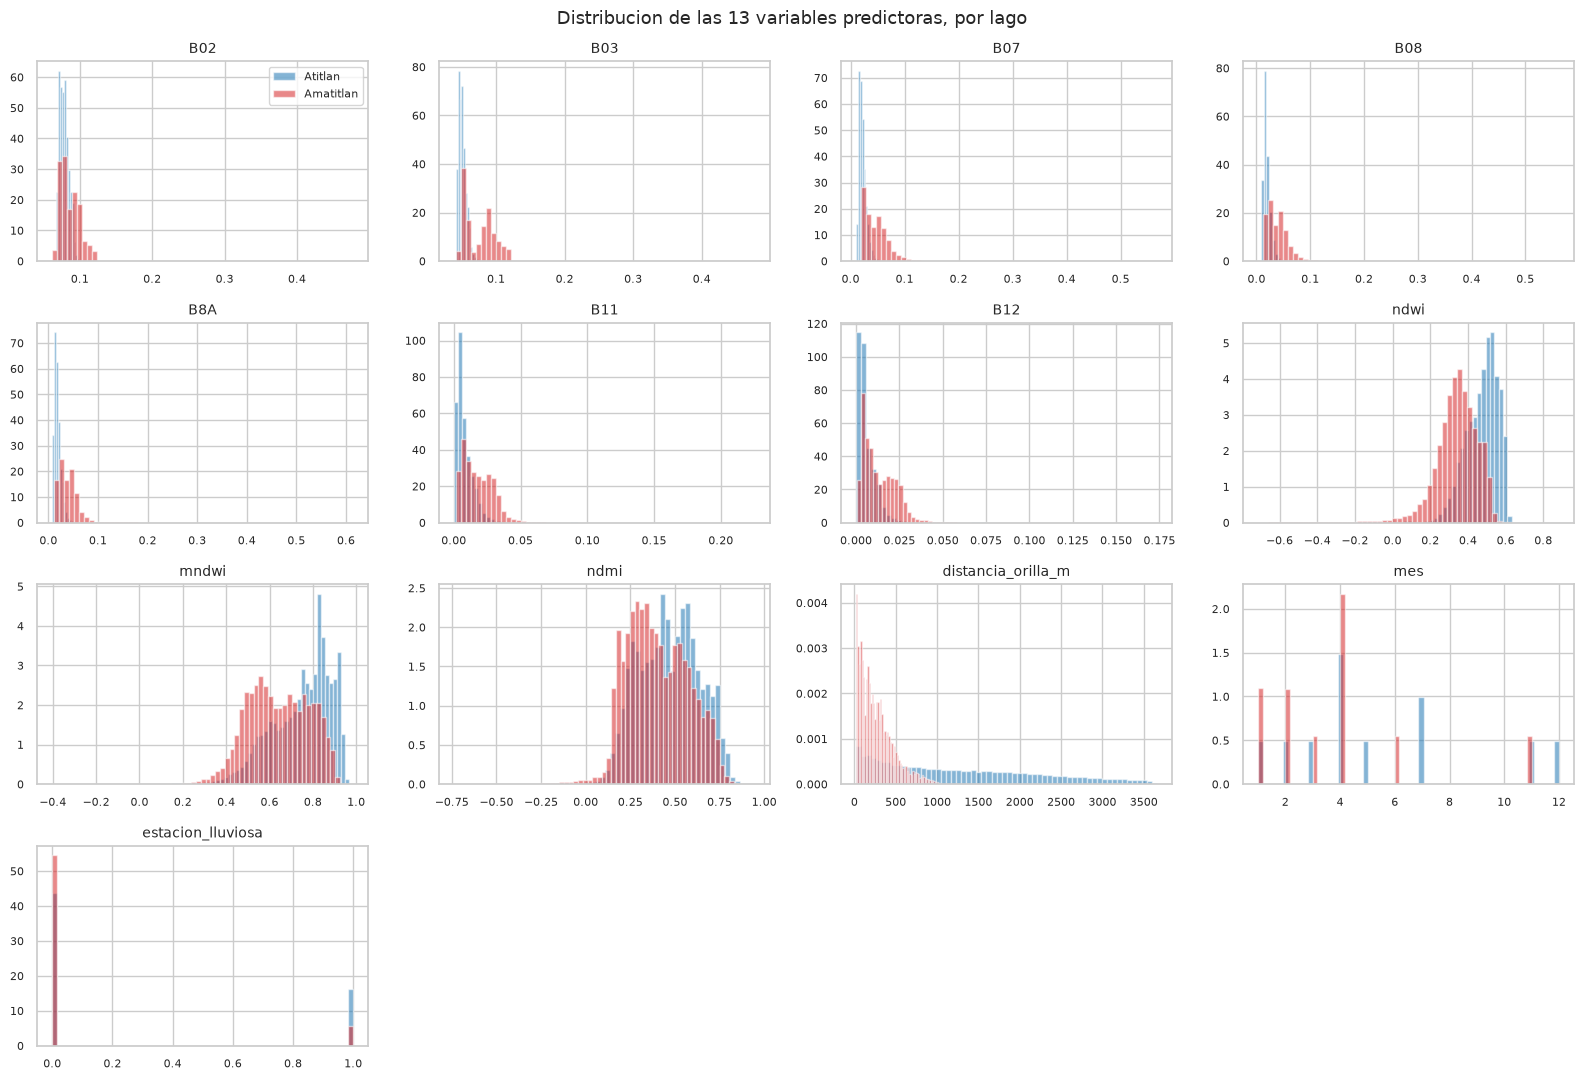

In [8]:
fig, ejes = plt.subplots(4, 4, figsize=(16, 11))
for eje, variable in zip(ejes.flat, dml.PREDICTORES):
    for lago in LAGOS:
        eje.hist(datos.loc[datos["lago"] == lago, variable], bins=60, alpha=0.55,
                 color=COLOR[lago], label=lago, density=True)
    eje.set_title(variable, fontsize=10)
    eje.tick_params(labelsize=8)
for eje in ejes.flat[len(dml.PREDICTORES):]:
    eje.axis("off")
ejes.flat[0].legend(fontsize=8)
fig.suptitle("Distribucion de las 13 variables predictoras, por lago", fontsize=13)
fig.tight_layout()
plt.show()

Los dos lagos ocupan rangos distintos en casi todas las bandas. **Amatitlán es sistemáticamente más reflectante** (B03 medio 0.076 frente a 0.051; B07 medio 0.048 frente a 0.022), lo cual hace sentido, pues cuenta con un agua mucho más cargada de material en suspensión y de algas. Las bandas del infrarrojo (B07, B08, B8A) muestran colas largas hacia la derecha, que son justamente los píxeles con floración. `distancia_orilla_m` refleja la diferencia de tamaño (llega a 3 660 m en Atitlán y apenas a unos cientos en Amatitlán).

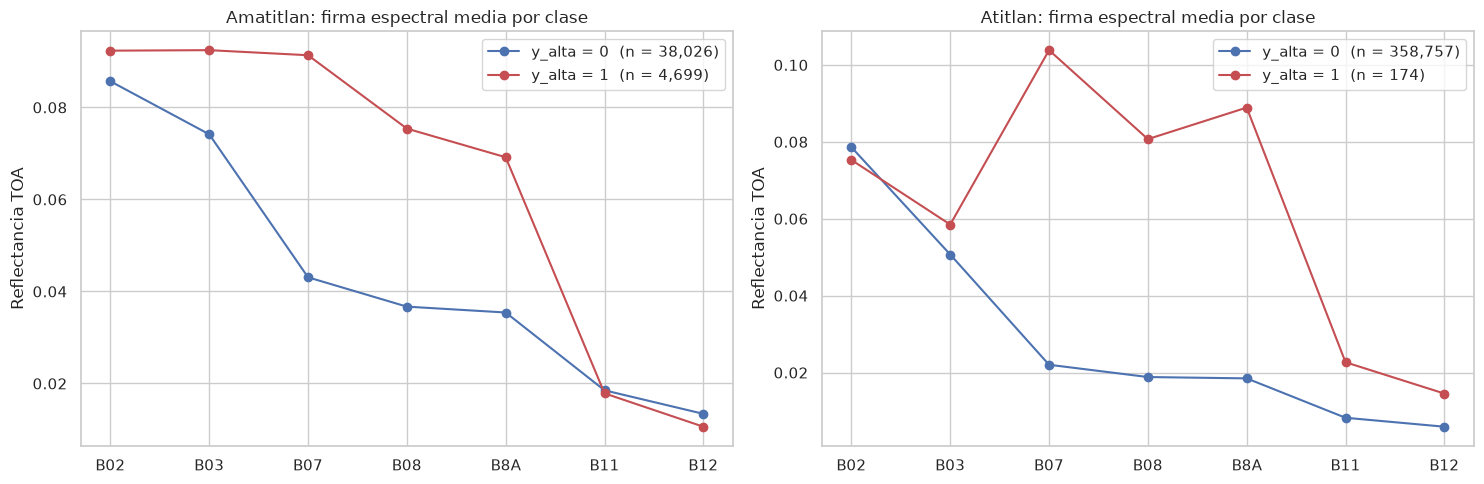

In [9]:
bandas = dml.BANDAS_PREDICTORAS
fig, ejes = plt.subplots(1, 2, figsize=(15, 5))
for eje, lago in zip(ejes, ["Amatitlan", "Atitlan"]):
    sub = datos[datos["lago"] == lago]
    for clase in (0, 1):
        parte = sub[sub["y_alta"] == clase]
        if parte.empty:
            continue
        eje.plot(bandas, parte[bandas].mean(), "o-", color=COLOR_CLASE[clase],
                 label=f"y_alta = {clase}  (n = {len(parte):,})")
    eje.set_title(f"{lago}: firma espectral media por clase")
    eje.set_ylabel("Reflectancia TOA")
    eje.legend()
fig.tight_layout()
plt.show()

**Las dos clases tienen firmas espectrales claramente distintas, y la diferencia está en el infrarrojo.** En Amatitlán, la clase de alta presencia casi duplica la reflectancia en B07 (0.091 frente a 0.043), B08 (0.075 frente a 0.037) y B8A (0.069 frente a 0.035), mientras que en el azul B02 apenas cambia (0.092 frente a 0.086). Ese es el comportamiento esperado de una floración, la vegetación acuática refleja intensamente en el infrarrojo cercano, igual que la vegetación terrestre. En cambio B11 y B12 (infrarrojo de onda corta) casi no se mueven, e incluso bajan.

Este es un resultado importante para el modelado. **Existe señal separable en bandas que no participan en la construcción de la etiqueta**, así que el problema no es trivialmente imposible una vez retiradas las variables con fuga.

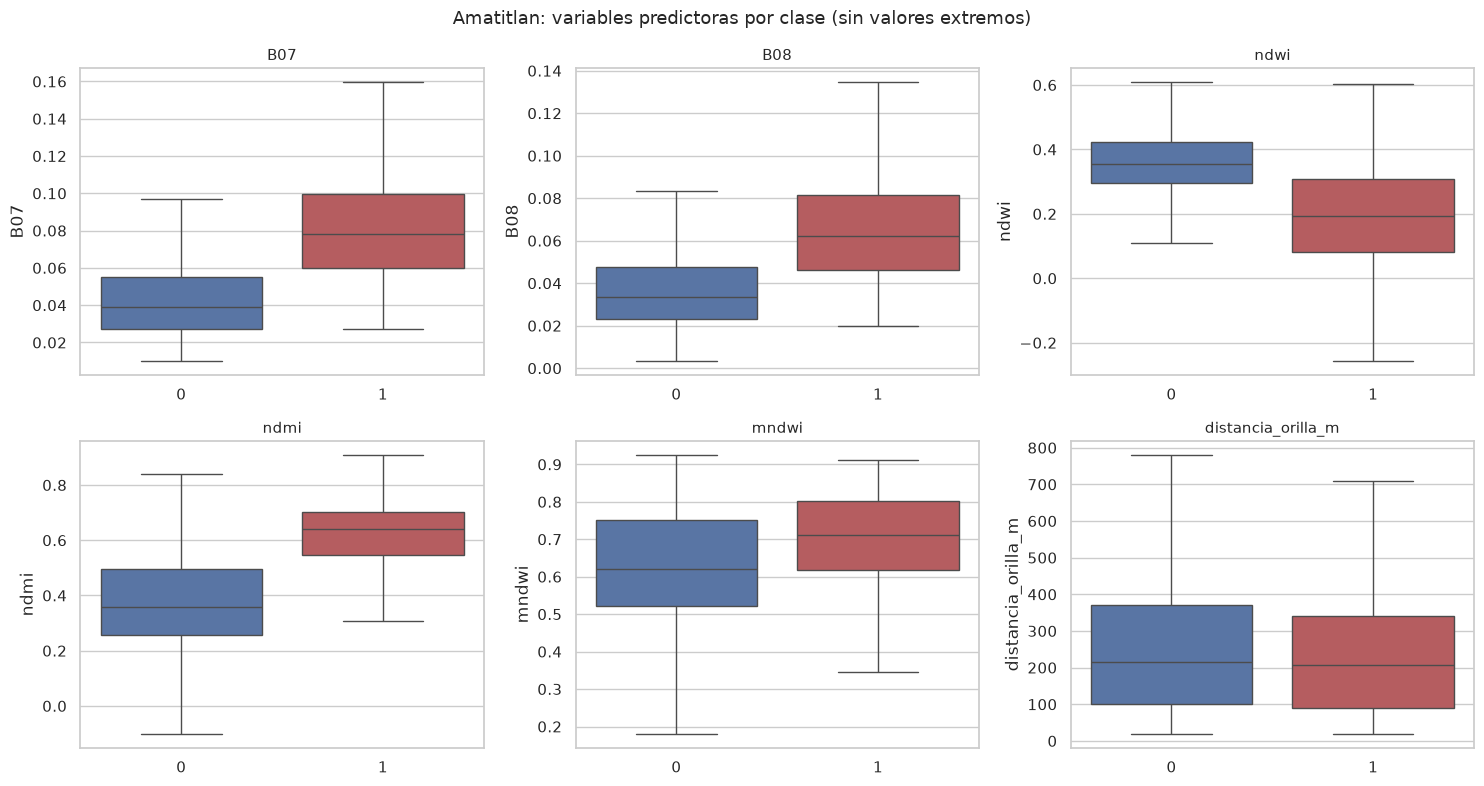

In [10]:
variables_clave = ["B07", "B08", "ndwi", "ndmi", "mndwi", "distancia_orilla_m"]
amatitlan = datos[datos["lago"] == "Amatitlan"]

fig, ejes = plt.subplots(2, 3, figsize=(15, 8))
for eje, variable in zip(ejes.flat, variables_clave):
    sns.boxplot(data=amatitlan, x="y_alta", y=variable, ax=eje,
                palette=[COLOR_CLASE[0], COLOR_CLASE[1]], showfliers=False)
    eje.set_title(variable, fontsize=11)
    eje.set_xlabel("")
fig.suptitle("Amatitlan: variables predictoras por clase (sin valores extremos)", fontsize=13)
fig.tight_layout()
plt.show()

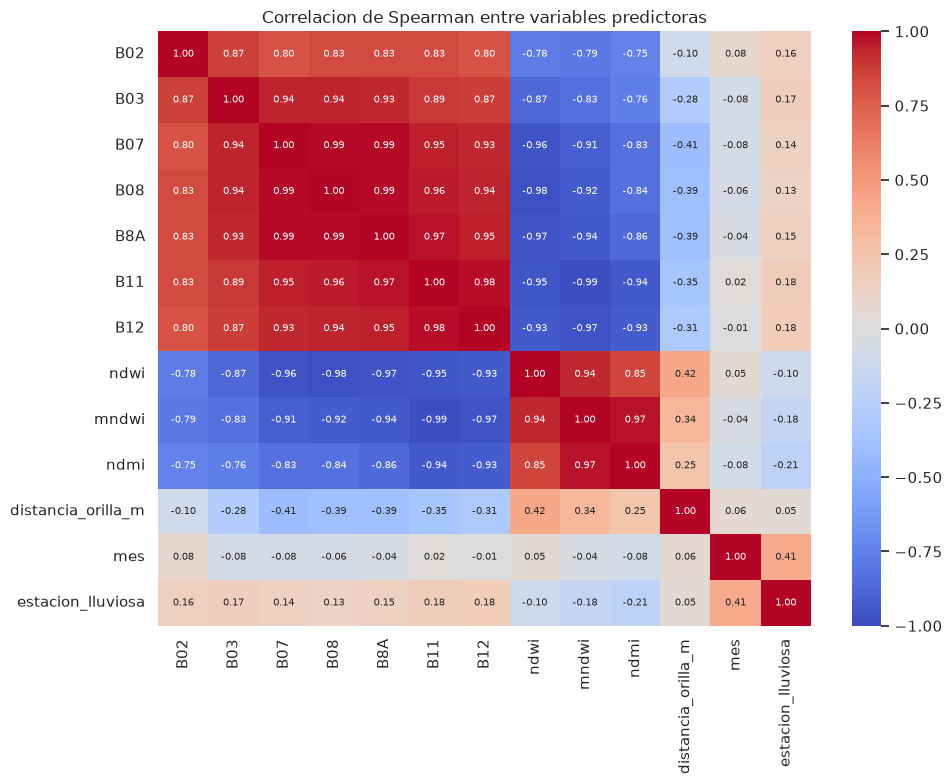

Pares con |correlacion| > 0.9: 27
  B11                  mndwi                -0.989
  B07                  B08                  +0.987
  B07                  B8A                  +0.987
  B08                  B8A                  +0.987
  B08                  ndwi                 -0.981
  B11                  B12                  +0.977
  mndwi                ndmi                 +0.970
  B11                  B8A                  +0.969
  B12                  mndwi                -0.969
  B8A                  ndwi                 -0.968


In [11]:
matriz = datos[dml.PREDICTORES].corr(method="spearman")

fig, eje = plt.subplots(figsize=(10, 8))
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, annot_kws={"size": 7}, ax=eje)
eje.set_title("Correlacion de Spearman entre variables predictoras")
fig.tight_layout()
plt.show()

pares = [
    (i, j, round(matriz.loc[i, j], 3))
    for i in matriz.index for j in matriz.columns
    if i < j and abs(matriz.loc[i, j]) > 0.9
]
print(f"Pares con |correlacion| > 0.9: {len(pares)}")
for a, b, r in sorted(pares, key=lambda x: -abs(x[2]))[:10]:
    print(f"  {a:20s} {b:20s} {r:+.3f}")

**Las variables predictoras están fuertemente correlacionadas entre sí.** Hay 27 pares con correlación de Spearman por encima de 0.9 en valor absoluto, y los más extremos son casi redundantes. B07-B08 y B08-B8A comparten ρ = 0.987, y B11-`mndwi` llega a −0.989. Esto tiene dos consecuencias prácticas:

1. La **Regresión Logística** sufrirá con esta colinealidad. Los coeficientes individuales se vuelven inestables y no se pueden leer como el efecto aislado de cada banda. Se mitiga con regularización.

2. Los **modelos de árboles** toleran bien la redundancia, pero la reparten. Si dos variables llevan la misma información, la importancia se divide arbitrariamente entre ambas.

No se eliminan variables por este motivo, porque ninguna es redundante *por construcción* y los tres modelos manejan la situación de formas distintas que conviene comparar.

In [ ]:
# Poder discriminante de cada variable por separado, medido con el AUC.
# Se calcula sobre Amatitlan, el único lago con ambas clases bien representadas.
auc_individual = pd.DataFrame(
    {
        "auc": [roc_auc_score(amatitlan["y_alta"], amatitlan[c]) for c in dml.PREDICTORES],
    },
    index=dml.PREDICTORES,
)
auc_individual["separacion"] = (auc_individual["auc"] - 0.5).abs() + 0.5
auc_individual["sentido"] = np.where(auc_individual["auc"] >= 0.5, "directo", "inverso")
auc_individual.sort_values("separacion", ascending=False).round(4)

,auc,separacion,sentido
B07,0.8952,0.8952,directo
ndmi,0.8813,0.8813,directo
B08,0.8550,0.8550,directo
ndwi,0.1719,0.8281,inverso
B8A,0.8131,0.8131,directo
B03,0.7652,0.7652,directo
mes,0.7168,0.7168,directo
estacion_lluviosa,0.6967,0.6967,directo
B02,0.6822,0.6822,directo
mndwi,0.6400,0.6400,directo


**Ninguna variable predictora resuelve el problema sola, pero varias tienen poder considerable.** Ordenadas por capacidad de separación: B07 (AUC 0.895), `ndmi` (0.881), B08 (0.855), `ndwi` (0.172, que equivale a 0.828 en sentido inverso) y B8A (0.813).

El caso del **NDWI merece atención**, su AUC de 0.172 significa que valores *bajos* de NDWI acompañan la alta presencia de cianobacteria. Es el mismo hallazgo de la Parte 1, donde el NDWI correlacionaba negativamente con la clorofila-a.

En el extremo opuesto, `B12` (0.441), `distancia_orilla_m` (0.471) y `B11` (0.483) son casi indiferentes vistas de forma aislada. Se conservan porque pueden aportar en combinación con las demás (los árboles las usan para condicionar) y porque `distancia_orilla_m` es la única variable espacial del conjunto.

### 1.6 Decisiones de preparación y limpieza

| Decisión | Motivo |
| --- | --- |
| Unidad de observación = píxel × fecha | Es el grano más fino disponible y el que permite reconstruir mapas predictivos después. |
| Restringir a la máscara fija del lago | Garantiza que todas las fechas se comparen sobre la misma superficie; la máscara por fecha haría que un cambio de área se confundiera con un cambio de floración. |
| Enmascarar nubes con SCL, no con umbrales propios | Reutiliza la clasificación oficial del producto L2A, ya validada, en lugar de reinventarla. |
| Exigir `chla` finita | Sin variable respuesta no hay observación; admitirla la etiquetaría como clase 0. |
| Recortar reflectancias negativas en 0 | La corrección radiométrica deja valores negativos hasta −0.066 que no tienen sentido físico como reflectancia. |
| Bandas del producto L1C | El *custom script* de cianobacteria está escrito para reflectancia tope de atmósfera; usar L2A cambiaría la escala respecto a la Parte 1. |
| Muestreo con fracción constante | Preserva prevalencia y proporciones; un muestreo balanceado distorsionaría la precisión y el PR-AUC. |
| No imputar | No hay faltantes que imputar, y un píxel no observado no es un valor perdido recuperable. |